# 🩹 Wound Tissue Segmentation
### Rood / Geel / Zwart weefsel detectie

**Door: Nika de Vries — Applied Data Science & AI, De Haagse Hogeschool**

---

## Pipeline overzicht

```
📸 Wond foto
    ↓
[STAP 1] Wond detectie (UWM model - binair masker)
    ↓
[STAP 2] Tissue kleur analyse (HSV segmentatie binnen wond)
    ↓
📊 Output: % Rood / % Geel / % Zwart
```

---

### ⚙️ Zorg dat je GPU hebt ingeschakeld!
> **Runtime → Change runtime type → T4 GPU**

## 📦 Cel 1: Installeer packages

In [1]:
# Installeer benodigde packages
!pip install segmentation-models-pytorch albumentations opencv-python-headless matplotlib tqdm -q

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  Geen GPU gevonden. Ga naar Runtime → Change runtime type → T4 GPU')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.1 MB/s eta 0:00:00
✅ Device: cuda
   GPU: Tesla T4


## 📥 Cel 2: Download dataset (UWM wound-segmentation)

In [2]:
# Clone de UWM wound-segmentation repo (dataset + code)
!git clone https://github.com/uwm-bigdata/wound-segmentation.git

# Bekijk de structuur
!find wound-segmentation/data -type d | head -20
print('\n📁 Bestanden in data folder:')
!ls wound-segmentation/data/

Cloning into 'wound-segmentation'...
remote: Enumerating objects: 3511, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 3511 (delta 153), reused 137 (delta 137), pack-reused 3338 (from 1)
Receiving objects: 100% (3511/3511), 338.80 MiB | 20.56 MiB/s, done.
Resolving deltas: 100% (1260/1260), done.
Updating files: 100% (2593/2593), done.
wound-segmentation/data
wound-segmentation/data/Medetec_foot_ulcer_224
wound-segmentation/data/Medetec_foot_ulcer_224/test
wound-segmentation/data/Medetec_foot_ulcer_224/test/predictions
wound-segmentation/data/Medetec_foot_ulcer_224/test/predictions/2019-12-19 01%3A53%3A15.480800
wound-segmentation/data/Medetec_foot_ulcer_224/test/images
wound-segmentation/data/Medetec_foot_ulcer_224/test/labels
wound-segmentation/data/Medetec_foot_ulcer_224/train
wound-segmentation/data/Medetec_foot_ulcer_224/train/images
wound-segmentation/data/Medetec_foot_ulcer_224/train/labels
wound-segmentation/

## 🔍 Cel 3: Verken de dataset

In [3]:
import glob

# Zoek afbeeldingen en maskers
# Pas pad aan als de structuur anders blijkt
BASE_DIR = 'wound-segmentation/data'

# Zoek alle image paden
all_images = glob.glob(f'{BASE_DIR}/**/*.jpg', recursive=True) + \
             glob.glob(f'{BASE_DIR}/**/*.png', recursive=True) + \
             glob.glob(f'{BASE_DIR}/**/*.jpeg', recursive=True)

print(f'📸 Totaal gevonden bestanden: {len(all_images)}')
print('\nVoorbeeldpaden:')
for p in all_images[:5]:
    print(f'  {p}')

# Zoek maskers apart
masks = [p for p in all_images if 'mask' in p.lower() or 'label' in p.lower() or 'annotation' in p.lower()]
images = [p for p in all_images if p not in masks]
print(f'\n🖼️  Foto\'s: {len(images)}')
print(f'🎭 Maskers: {len(masks)}')

📸 Totaal gevonden bestanden: 2548

Voorbeeldpaden:
  wound-segmentation/data/Medetec_foot_ulcer_224/test/predictions/2019-12-19 01%3A53%3A15.480800/foot-ulcer-0028_3.png
  wound-segmentation/data/Medetec_foot_ulcer_224/test/predictions/2019-12-19 01%3A53%3A15.480800/foot-ulcer-0028_2.png
  wound-segmentation/data/Medetec_foot_ulcer_224/test/predictions/2019-12-19 01%3A53%3A15.480800/foot-ulcer-0027_2.png
  wound-segmentation/data/Medetec_foot_ulcer_224/test/predictions/2019-12-19 01%3A53%3A15.480800/foot-ulcer-0027_3.png
  wound-segmentation/data/Medetec_foot_ulcer_224/test/predictions/2019-12-19 01%3A53%3A15.480800/foot-ulcer-0028.png

🖼️  Foto's: 1378
🎭 Maskers: 1170


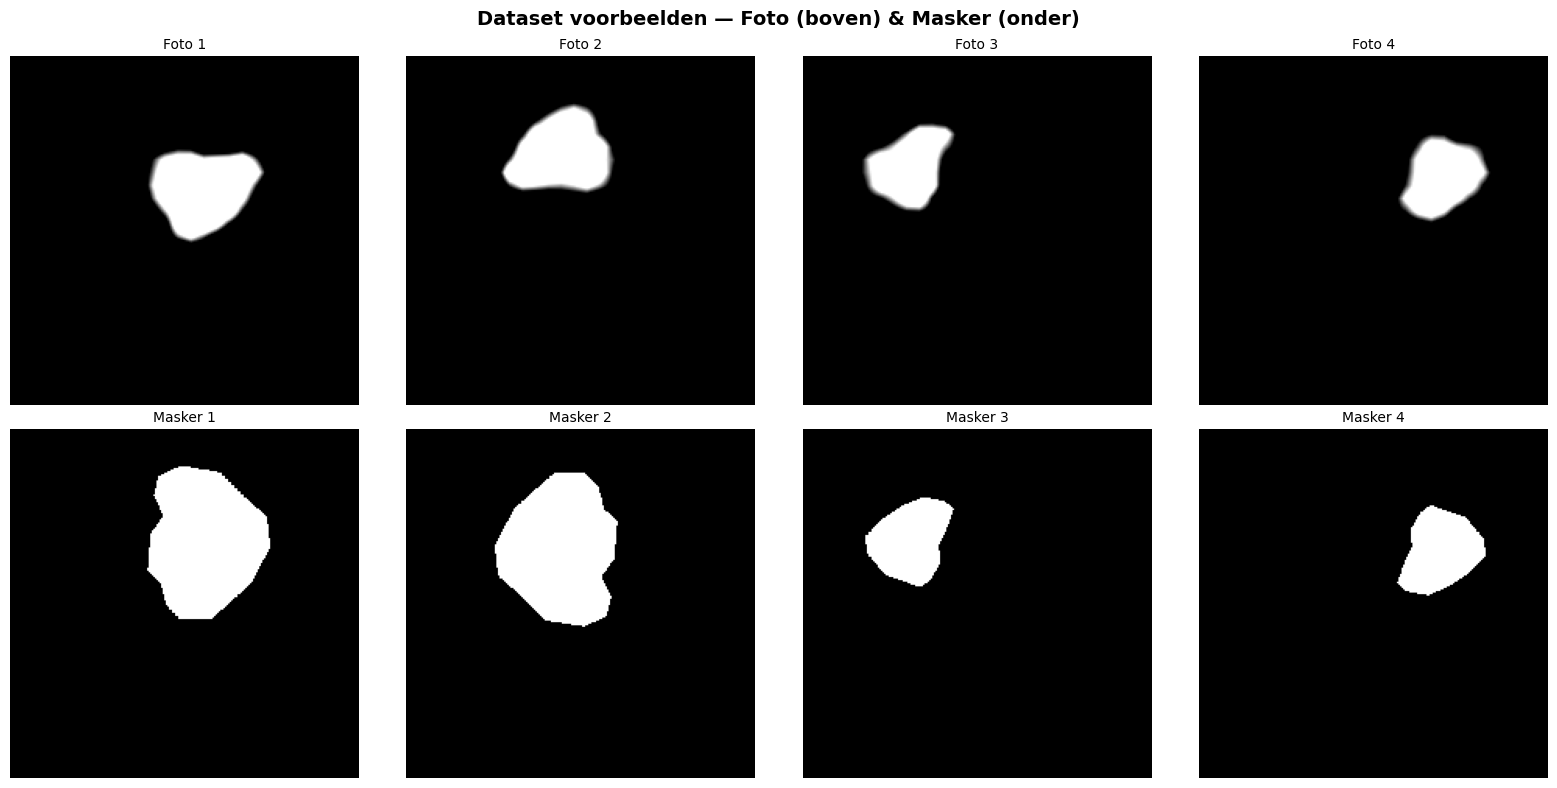

In [4]:
# Visualiseer een paar voorbeelden uit de dataset
def show_dataset_samples(image_paths, mask_paths, n=4):
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    fig.suptitle('Dataset voorbeelden — Foto (boven) & Masker (onder)', fontsize=14, fontweight='bold')

    for i in range(min(n, len(image_paths))):
        img = cv2.imread(image_paths[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(img)
        axes[0, i].set_title(f'Foto {i+1}', fontsize=10)
        axes[0, i].axis('off')

        if i < len(mask_paths):
            mask = cv2.imread(mask_paths[i], cv2.IMREAD_GRAYSCALE)
            axes[1, i].imshow(mask, cmap='gray')
            axes[1, i].set_title(f'Masker {i+1}', fontsize=10)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

if len(images) > 0 and len(masks) > 0:
    show_dataset_samples(images[:4], masks[:4])
else:
    print('⚠️ Controleer de mapstructuur handmatig:')
    !ls wound-segmentation/data/

## 🗂️ Cel 4: Dataset class aanmaken

In [17]:
# ── CONFIG ────────────────────────────────────────────────
IMG_SIZE   = 256      # kleiner = sneller trainen op Colab
BATCH_SIZE = 8
NUM_EPOCHS = 20
LR         = 1e-4
VAL_SPLIT  = 0.2
# ──────────────────────────────────────────────────────────

class WoundDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img  = cv2.imread(self.image_paths[idx])
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        # Normaliseer masker naar 0/1
        mask = (mask > 127).astype(np.uint8)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask']

        return img, mask.long()

# Augmentaties
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], is_check_shapes=False)

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], is_check_shapes=False)

# Train/val split
from sklearn.model_selection import train_test_split

train_pairs, val_pairs = train_test_split(pairs, test_size=VAL_SPLIT, random_state=42)

train_imgs,  train_masks = zip(*train_pairs)
val_imgs,    val_masks   = zip(*val_pairs)

train_ds = WoundDataset(list(train_imgs), list(train_masks), train_transform)
val_ds   = WoundDataset(list(val_imgs),   list(val_masks),   val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'✅ Train samples : {len(train_ds)}')
print(f'✅ Val samples   : {len(val_ds)}')
print(f'✅ Batch size    : {BATCH_SIZE}')
print(f'✅ Input grootte : {IMG_SIZE}x{IMG_SIZE}')

✅ Train samples : 788
✅ Val samples   : 198
✅ Batch size    : 8
✅ Input grootte : 256x256


In [18]:
# Debug: check of images en maskers correct gekoppeld zijn
print("=== EERSTE 5 PAREN ===")
for i in range(min(5, len(train_imgs))):
    print(f"IMG:  {train_imgs[i]}")
    print(f"MASK: {train_masks[i]}")
    print()

# Check of maskers ook echt wit/zwart zijn
import cv2
import numpy as np

mask = cv2.imread(train_masks[0], cv2.IMREAD_GRAYSCALE)
print(f"Masker unieke waarden: {np.unique(mask)}")
print(f"Masker max waarde: {mask.max()}")
print(f"Masker grootte: {mask.shape}")

img = cv2.imread(train_imgs[0])
print(f"Foto grootte: {img.shape}")

=== EERSTE 5 PAREN ===
IMG:  wound-segmentation/data/Foot Ulcer Segmentation Challenge/train/images/0978.png
MASK: wound-segmentation/data/Foot Ulcer Segmentation Challenge/train/labels/0978.png

IMG:  wound-segmentation/data/Foot Ulcer Segmentation Challenge/train/images/0425.png
MASK: wound-segmentation/data/Foot Ulcer Segmentation Challenge/train/labels/0425.png

IMG:  wound-segmentation/data/Foot Ulcer Segmentation Challenge/validation/images/0516.png
MASK: wound-segmentation/data/Foot Ulcer Segmentation Challenge/validation/labels/0516.png

IMG:  wound-segmentation/data/Foot Ulcer Segmentation Challenge/train/images/0677.png
MASK: wound-segmentation/data/Foot Ulcer Segmentation Challenge/train/labels/0677.png

IMG:  wound-segmentation/data/Foot Ulcer Segmentation Challenge/train/images/0601.png
MASK: wound-segmentation/data/Foot Ulcer Segmentation Challenge/train/labels/0601.png

Masker unieke waarden: [  0 255]
Masker max waarde: 255
Masker grootte: (512, 512)
Foto grootte: (512,

✅ Gevonden geldige paren: 986

Voorbeeld paar:
  IMG:  wound-segmentation/data/Foot Ulcer Segmentation Challenge/train/images/0011.png
  MASK: wound-segmentation/data/Foot Ulcer Segmentation Challenge/train/labels/0011.png


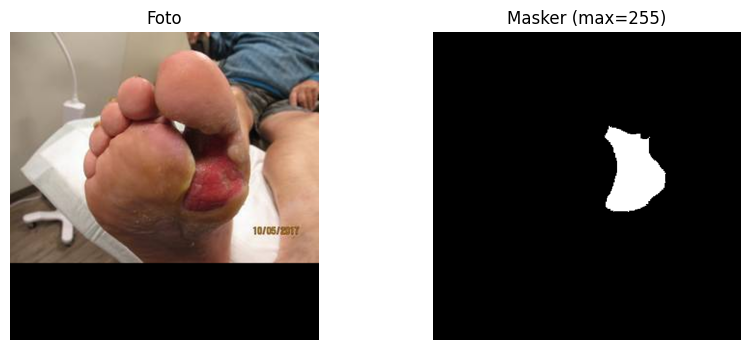

In [19]:
import os, glob

# Correcte aanpak: koppel op bestandsnaam
def get_matched_pairs(base_dir):
    pairs = []
    for split in ['train', 'validation']:
        img_dir  = os.path.join(base_dir, 'Foot Ulcer Segmentation Challenge', split, 'images')
        mask_dir = os.path.join(base_dir, 'Foot Ulcer Segmentation Challenge', split, 'labels')

        if not os.path.exists(img_dir):
            print(f"⚠️ Map niet gevonden: {img_dir}")
            continue

        for img_path in sorted(glob.glob(f"{img_dir}/*.png")):
            filename  = os.path.basename(img_path)
            mask_path = os.path.join(mask_dir, filename)  # zelfde naam!

            if os.path.exists(mask_path):
                # Check of masker niet leeg is
                m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                if m is not None and m.max() > 0:
                    pairs.append((img_path, mask_path))

    return pairs

pairs = get_matched_pairs('wound-segmentation/data')
print(f"✅ Gevonden geldige paren: {len(pairs)}")

if len(pairs) > 0:
    print("\nVoorbeeld paar:")
    print(f"  IMG:  {pairs[0][0]}")
    print(f"  MASK: {pairs[0][1]}")

    # Visualiseer eerste paar
    img  = cv2.imread(pairs[0][0])
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(pairs[0][1], cv2.IMREAD_GRAYSCALE)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img);  ax1.set_title('Foto');   ax1.axis('off')
    ax2.imshow(mask, cmap='gray'); ax2.set_title(f'Masker (max={mask.max()})'); ax2.axis('off')
    plt.show()

## 🧠 Cel 5: Model bouwen (U-Net met ResNet34 backbone)

In [20]:
# U-Net model via segmentation_models_pytorch
# ResNet34 backbone = goede balans tussen snelheid en nauwkeurigheid
model = smp.Unet(
    encoder_name    = 'resnet34',     # backbone
    encoder_weights = 'imagenet',     # pretrained weights
    in_channels     = 3,              # RGB input
    classes         = 1,              # binaire segmentatie: wond ja/nee
    activation      = None,           # we gebruiken BCEWithLogitsLoss
).to(device)

# Loss en optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

# Dice score functie (standaard maat bij medische segmentatie)
def dice_score(pred, target, threshold=0.5):
    pred   = (torch.sigmoid(pred) > threshold).float()
    target = target.float()
    intersection = (pred * target).sum()
    return (2. * intersection + 1e-8) / (pred.sum() + target.sum() + 1e-8)

# Tel parameters
total_params = sum(p.numel() for p in model.parameters())
print(f'✅ Model geladen: U-Net + ResNet34')
print(f'   Parameters  : {total_params:,}')
print(f'   Device      : {device}')

✅ Model geladen: U-Net + ResNet34
   Parameters  : 24,436,369
   Device      : cuda


## 🏋️ Cel 6: Training loop

In [21]:
train_losses, val_losses = [], []
train_dices,  val_dices  = [], []
best_val_dice = 0.0

print(f'🚀 Training gestart — {NUM_EPOCHS} epochs\n')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Val Loss":>10} | {"Train Dice":>10} | {"Val Dice":>10}')
print('-' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    # ── TRAIN ──
    model.train()
    t_loss, t_dice = 0.0, 0.0

    for imgs, masks_batch in train_loader:
        imgs        = imgs.to(device).float()
        masks_batch = masks_batch.to(device).unsqueeze(1).float()

        optimizer.zero_grad()
        preds = model(imgs)
        loss  = criterion(preds, masks_batch)
        loss.backward()
        optimizer.step()

        t_loss += loss.item()
        t_dice += dice_score(preds, masks_batch).item()

    t_loss /= len(train_loader)
    t_dice /= len(train_loader)

    # ── VALIDATIE ──
    model.eval()
    v_loss, v_dice = 0.0, 0.0

    with torch.no_grad():
        for imgs, masks_batch in val_loader:
            imgs        = imgs.to(device).float()
            masks_batch = masks_batch.to(device).unsqueeze(1).float()
            preds       = model(imgs)
            v_loss     += criterion(preds, masks_batch).item()
            v_dice     += dice_score(preds, masks_batch).item()

    v_loss /= len(val_loader)
    v_dice /= len(val_loader)

    scheduler.step(v_loss)

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_dices.append(t_dice)
    val_dices.append(v_dice)

    # Sla beste model op
    if v_dice > best_val_dice:
        best_val_dice = v_dice
        torch.save(model.state_dict(), 'best_wound_model.pth')
        star = ' ⭐ (nieuw beste!)'
    else:
        star = ''

    print(f'{epoch:>6} | {t_loss:>10.4f} | {v_loss:>10.4f} | {t_dice:>10.4f} | {v_dice:>10.4f}{star}')

print(f'\n✅ Training klaar! Beste val Dice: {best_val_dice:.4f}')

🚀 Training gestart — 20 epochs

 Epoch | Train Loss |   Val Loss | Train Dice |   Val Dice
------------------------------------------------------------
     1 |     0.4102 |     0.2656 |     0.1937 |     0.3265 ⭐ (nieuw beste!)
     2 |     0.2070 |     0.1734 |     0.6090 |     0.7115 ⭐ (nieuw beste!)
     3 |     0.1505 |     0.1307 |     0.7188 |     0.7646 ⭐ (nieuw beste!)
     4 |     0.1153 |     0.1314 |     0.7652 |     0.6097
     5 |     0.0917 |     0.0848 |     0.7858 |     0.7541
     6 |     0.0730 |     0.0682 |     0.8088 |     0.7449
     7 |     0.0594 |     0.0539 |     0.8156 |     0.8111 ⭐ (nieuw beste!)
     8 |     0.0485 |     0.0469 |     0.8435 |     0.8016
     9 |     0.0417 |     0.0383 |     0.8358 |     0.8281 ⭐ (nieuw beste!)
    10 |     0.0360 |     0.0320 |     0.8427 |     0.8508 ⭐ (nieuw beste!)
    11 |     0.0311 |     0.0288 |     0.8499 |     0.8415
    12 |     0.0274 |     0.0258 |     0.8593 |     0.8474
    13 |     0.0244 |     0.0223 |    

## 📈 Cel 7: Training curves visualiseren

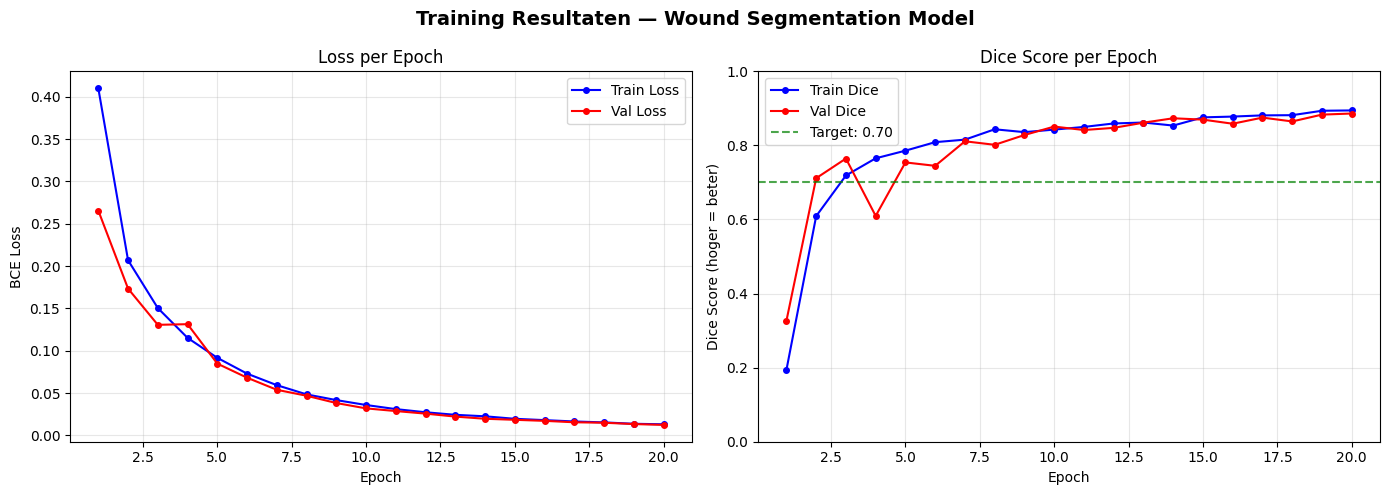

Beste Dice score: 0.8861


In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Resultaten — Wound Segmentation Model', fontsize=14, fontweight='bold')

epochs_range = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs_range, train_losses, 'b-o', markersize=4, label='Train Loss')
ax1.plot(epochs_range, val_losses,   'r-o', markersize=4, label='Val Loss')
ax1.set_title('Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs_range, train_dices, 'b-o', markersize=4, label='Train Dice')
ax2.plot(epochs_range, val_dices,   'r-o', markersize=4, label='Val Dice')
ax2.set_title('Dice Score per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice Score (hoger = beter)')
ax2.set_ylim([0, 1])
ax2.axhline(y=0.7, color='g', linestyle='--', alpha=0.7, label='Target: 0.70')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Beste Dice score: {best_val_dice:.4f}')

## 🎨 Cel 8: STAP 2 — Tissue Kleur Analyse (Rood / Geel / Zwart)

Nu gebruiken we het wond-masker van stap 1, en analyseren we **binnen** de wond welk weefsel aanwezig is op basis van HSV kleurruimte.

In [23]:
def predict_wound_mask(model, image_path, device, img_size=256):
    """Stap 1: Detecteer de wond (binair masker)"""
    transform = A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])

    img_orig = cv2.imread(image_path)
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    h_orig, w_orig = img_orig.shape[:2]

    img_t = transform(image=img_orig)['image'].unsqueeze(0).float().to(device)

    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(img_t)).squeeze().cpu().numpy()

    # Resize masker terug naar originele afmeting
    mask = (pred > 0.5).astype(np.uint8) * 255
    mask = cv2.resize(mask, (w_orig, h_orig), interpolation=cv2.INTER_NEAREST)

    return img_orig, mask


def analyse_tissue_kleuren(img_rgb, wound_mask):
    """
    Stap 2: Analyseer tissue kleuren BINNEN de wond.

    Gebaseerd op klinische kleurcodering:
    🔴 ROOD  = granulatie weefsel (gezond, helend)
    🟡 GEEL  = fibrine / slough (afstervend)
    ⚫ ZWART = necrose / eschar (dood weefsel)
    """
    # Converteer naar HSV voor betere kleurdetectie
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

    # Maak masker boolean
    wound_bool = wound_mask > 127

    # ── KLEUR DREMPELWAARDEN (HSV) ──────────────────────────
    # Rood: hue 0-10 of 160-180, saturation hoog, value hoog
    red_mask1 = cv2.inRange(hsv, np.array([0,  80,  60]), np.array([10,  255, 255]))
    red_mask2 = cv2.inRange(hsv, np.array([160, 80,  60]), np.array([180, 255, 255]))
    red_mask  = cv2.bitwise_or(red_mask1, red_mask2)

    # Geel/oranje: hue 15-40, saturation hoog
    yellow_mask = cv2.inRange(hsv, np.array([15, 50, 80]), np.array([40, 255, 255]))

    # Zwart/donker: value laag
    black_mask = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 60]))
    # ────────────────────────────────────────────────────────

    # Combineer maskers met wondgebied
    wound_uint8 = wound_bool.astype(np.uint8) * 255
    red_in_wound    = cv2.bitwise_and(red_mask,    wound_uint8)
    yellow_in_wound = cv2.bitwise_and(yellow_mask, wound_uint8)
    black_in_wound  = cv2.bitwise_and(black_mask,  wound_uint8)

    # Tel pixels
    total_wound = wound_bool.sum()

    if total_wound == 0:
        return None, None

    n_red    = (red_in_wound > 0).sum()
    n_yellow = (yellow_in_wound > 0).sum()
    n_black  = (black_in_wound > 0).sum()

    # Overige pixels in de wond
    n_other = total_wound - n_red - n_yellow - n_black
    n_other = max(0, n_other)

    percentages = {
        'rood (granulatie)':  round(n_red    / total_wound * 100, 1),
        'geel (fibrine)':     round(n_yellow / total_wound * 100, 1),
        'zwart (necrose)':    round(n_black  / total_wound * 100, 1),
        'overig':             round(n_other  / total_wound * 100, 1),
    }

    # Maak visualisatie masker
    tissue_map = np.zeros((*wound_bool.shape, 3), dtype=np.uint8)
    tissue_map[red_in_wound    > 0] = [220,  50,  50]  # rood
    tissue_map[yellow_in_wound > 0] = [230, 200,  50]  # geel
    tissue_map[black_in_wound  > 0] = [ 40,  40,  40]  # zwart/donkergrijs
    tissue_map[wound_bool & (tissue_map.sum(axis=2) == 0)] = [180, 180, 180]  # overig grijs

    return percentages, tissue_map


def visualiseer_resultaat(image_path, model, device):
    """Volledige pipeline: foto → masker → tissue analyse → visualisatie"""

    # Stap 1: wond detectie
    img, wound_mask = predict_wound_mask(model, image_path, device)

    # Stap 2: tissue analyse
    percentages, tissue_map = analyse_tissue_kleuren(img, wound_mask)

    if percentages is None:
        print('⚠️ Geen wond gedetecteerd in deze foto.')
        return

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle('Wound Tissue Analyse Resultaat', fontsize=14, fontweight='bold')

    axes[0].imshow(img)
    axes[0].set_title('Originele foto', fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(wound_mask, cmap='Reds')
    axes[1].set_title('Stap 1: Wond masker', fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(tissue_map)
    legend_elements = [
        mpatches.Patch(color='#DC3232', label='Rood (granulatie)'),
        mpatches.Patch(color='#E6C832', label='Geel (fibrine)'),
        mpatches.Patch(color='#282828', label='Zwart (necrose)'),
        mpatches.Patch(color='#B4B4B4', label='Overig weefsel'),
    ]
    axes[2].legend(handles=legend_elements, loc='lower left', fontsize=7)
    axes[2].set_title('Stap 2: Tissue kleurenkaart', fontweight='bold')
    axes[2].axis('off')

    # Staafdiagram
    labels = list(percentages.keys())
    values = list(percentages.values())
    colors = ['#DC3232', '#E6C832', '#282828', '#B4B4B4']
    bars   = axes[3].barh(labels, values, color=colors, edgecolor='white', linewidth=0.5)
    axes[3].set_xlim(0, 100)
    axes[3].set_xlabel('Percentage (%)')
    axes[3].set_title('Tissue verdeling', fontweight='bold')
    for bar, val in zip(bars, values):
        axes[3].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{val}%', va='center', fontsize=10, fontweight='bold')
    axes[3].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('tissue_analyse_resultaat.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print samenvatting
    print('\n📊 TISSUE ANALYSE RESULTAAT')
    print('═' * 35)
    for tissue, pct in percentages.items():
        emoji = {'rood (granulatie)': '🔴', 'geel (fibrine)': '🟡',
                 'zwart (necrose)': '⚫', 'overig': '⬜'}.get(tissue, '▪️')
        bar   = '█' * int(pct / 2)
        print(f'{emoji} {tissue:<22} {pct:>5.1f}%  {bar}')
    print('═' * 35)

print('✅ Functies klaar! Ga naar Cel 9 om te testen.')

✅ Functies klaar! Ga naar Cel 9 om te testen.


## 🧪 Cel 9: Test op een afbeelding uit de dataset

✅ Beste model geladen
🖼️  Test afbeelding: wound-segmentation/data/Foot Ulcer Segmentation Challenge/train/images/0779.png


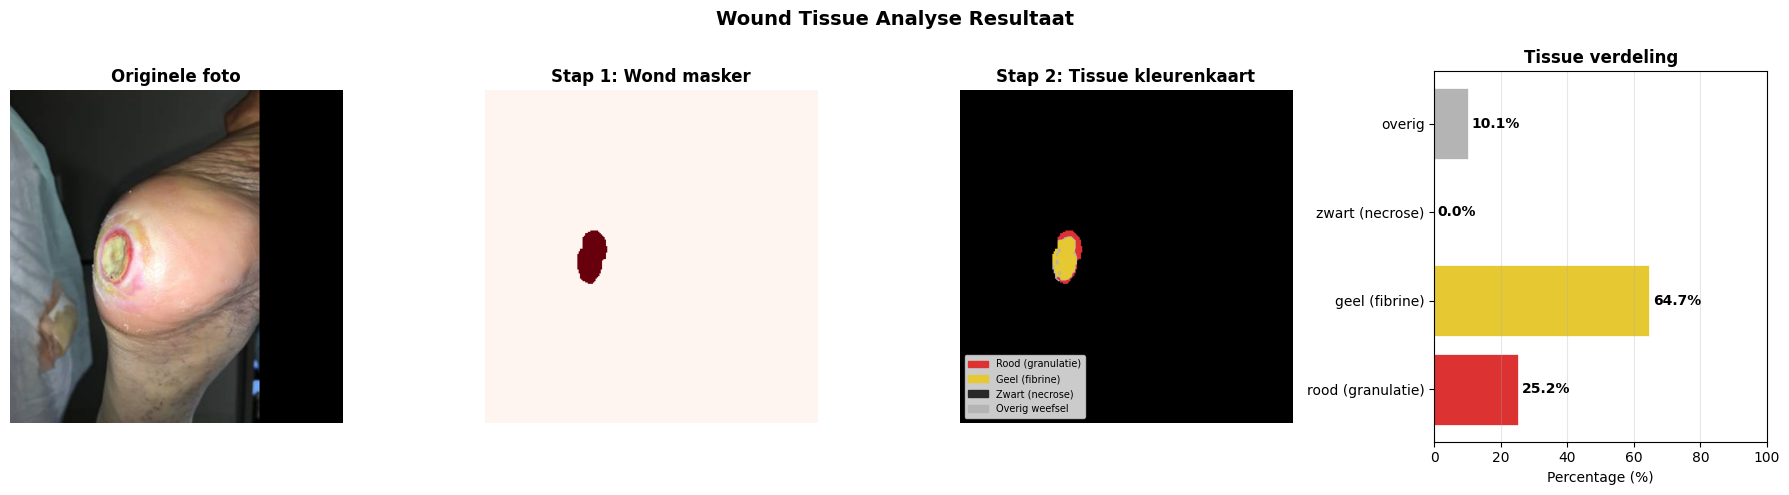


📊 TISSUE ANALYSE RESULTAAT
═══════════════════════════════════
🔴 rood (granulatie)       25.2%  ████████████
🟡 geel (fibrine)          64.7%  ████████████████████████████████
⚫ zwart (necrose)          0.0%  
⬜ overig                  10.1%  █████
═══════════════════════════════════


In [24]:
# Laad beste model
model.load_state_dict(torch.load('best_wound_model.pth', map_location=device))
print('✅ Beste model geladen')

# Test op een val afbeelding
test_image_path = val_imgs[0]  # eerste val afbeelding
print(f'🖼️  Test afbeelding: {test_image_path}')

visualiseer_resultaat(test_image_path, model, device)

## 📸 Cel 10: Upload je eigen wond foto!

📤 Upload een wond foto (jpg of png)...


Saving 400ArterieelVoorDotter.jpg to 400ArterieelVoorDotter.jpg

🔬 Analyseren: 400ArterieelVoorDotter.jpg


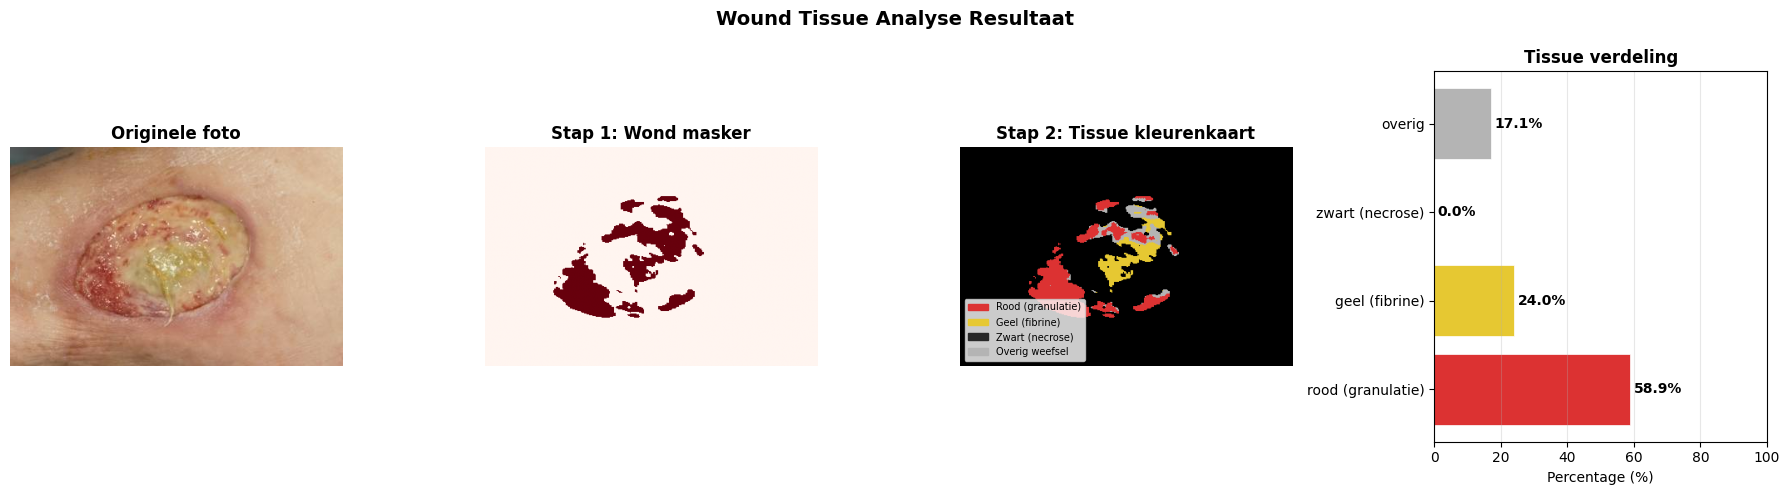


📊 TISSUE ANALYSE RESULTAAT
═══════════════════════════════════
🔴 rood (granulatie)       58.9%  █████████████████████████████
🟡 geel (fibrine)          24.0%  ████████████
⚫ zwart (necrose)          0.0%  
⬜ overig                  17.1%  ████████
═══════════════════════════════════


In [25]:
from google.colab import files

print('📤 Upload een wond foto (jpg of png)...')
uploaded = files.upload()

for filename, data in uploaded.items():
    with open(filename, 'wb') as f:
        f.write(data)
    print(f'\n🔬 Analyseren: {filename}')
    visualiseer_resultaat(filename, model, device)

## 💾 Cel 11: Sla model op naar Google Drive


In [26]:
# Optioneel: sla op naar Google Drive zodat je het later kunt hergebruiken
from google.colab import drive

drive.mount('/content/drive')

import shutil
save_path = '/content/drive/MyDrive/wound_model/'
os.makedirs(save_path, exist_ok=True)

shutil.copy('best_wound_model.pth', save_path + 'best_wound_model.pth')
shutil.copy('training_curves.png',  save_path + 'training_curves.png')

print(f'✅ Model opgeslagen naar: {save_path}')

Mounted at /content/drive
✅ Model opgeslagen naar: /content/drive/MyDrive/wound_model/


In [27]:
import os

# Maak een nette mapstructuur
os.makedirs('wound_tissue_project/data',    exist_ok=True)
os.makedirs('wound_tissue_project/outputs', exist_ok=True)

# Kopieer relevante bestanden
import shutil
shutil.copy('best_wound_model.pth',       'wound_tissue_project/')
shutil.copy('training_curves.png',        'wound_tissue_project/outputs/')
shutil.copy('tissue_analyse_resultaat.png','wound_tissue_project/outputs/')

print("✅ Bestanden klaar")
os.listdir('wound_tissue_project/')

✅ Bestanden klaar


['data', 'best_wound_model.pth', 'outputs']

---
## 📝 Notities & volgende stappen

### Wat dit model doet:
- **Stap 1:** U-Net detecteert *waar* de wond is (binaire segmentatie)
- **Stap 2:** HSV kleuranalyse bepaalt tissue type *binnen* de wond

### Verbeteringen voor later:
1. **Multi-klasse U-Net** trainen met gelabelde rood/geel/zwart data (Roboflow)
2. **Kalibratie** verbeteren: HSV drempelwaarden aanpassen op basis van jouw klinische kennis
3. **Data augmentatie** uitbreiden voor betere generalisatie
4. **Gradio app** bouwen voor eenvoudige demo

### Referenties:
- Wang et al. (2020). Fully automatic wound segmentation with deep convolutional neural networks. *Scientific Reports*.
- Dataset: github.com/uwm-bigdata/wound-segmentation
- segmentation_models_pytorch: github.com/qubvel/segmentation_models.pytorch